In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
import os
import OptimalBattery.global_config as gcf
import OptimalBattery.util as ut



In [2]:
data_path = gcf.data_path

# build transition matrix for visualization only...

In [3]:
dat_file = df = pd.read_csv(f"{data_path}/Cerebellum/super_cerebellum/sc1/data/s16/sc1_s16.dat", delim_whitespace=True, header=0)
filtered_dat = dat_file[dat_file["runNum"] >= 51].copy()
filtered_dat["run"] = filtered_dat["runNum"] - 50
filtered_dat = filtered_dat.drop(columns=["runNum"])
filtered_dat = filtered_dat.rename(columns={"taskName": "task_name"})

# Cerebellum

In [13]:
# define atlas and dirs
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)
n_sub, n_reg,n_vox = data_mdtb_s1_run.shape

cond_vec = info_mdtb_1_run['task_num'].values
part_vec  = info_mdtb_1_run["run"].values

# Remove task mean from each task condition for all runs
data_residual = data_mdtb_s1_run.copy()
for t in np.unique(cond_vec):
    mask = (cond_vec == t)
    task_mean = data_mdtb_s1_run[:, mask, :].mean(axis=1, keepdims=True)
    data_residual[:, mask, :] = data_mdtb_s1_run[:, mask, :] - task_mean
    

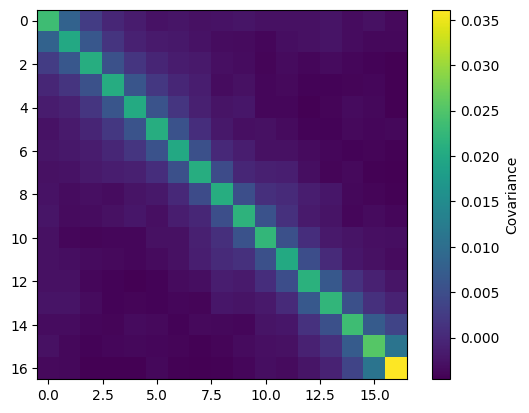

In [14]:
# add true order to info
info_with_order = ut.add_original_order(info_mdtb_1_run,filtered_dat)

# get the sort order based on (run, task_num_orig)
sort_order = info_with_order.sort_values(by=["run", "task_num_orig"]).index


# resort the info and data using the task_num_orig
info_sorted = info_with_order.loc[sort_order].reset_index(drop=True)
data_sorted = data_residual[:, sort_order, :]


n_runs = len(np.unique(info_sorted["run"]))
n_tasks = len(np.unique(info_sorted["task_num_orig"]))

cov_mats_runs = np.zeros((n_sub, n_runs, n_tasks, n_tasks))
for r, run in enumerate(np.unique(info_sorted["run"])):
    mask = info_sorted["run"].values == run
    conds = info_sorted.loc[mask, "task_num_orig"].values

    for s in range(n_sub):
        X = data_sorted[s, mask, :] 
        cov_mats_runs[s, r] = np.cov(X, rowvar=True)

cov_mats_per_subj = cov_mats_runs.mean(axis=1)
cov_mat_avg = cov_mats_per_subj.mean(axis=0)

plt.imshow(cov_mat_avg, cmap='viridis')
plt.colorbar(label='Covariance')


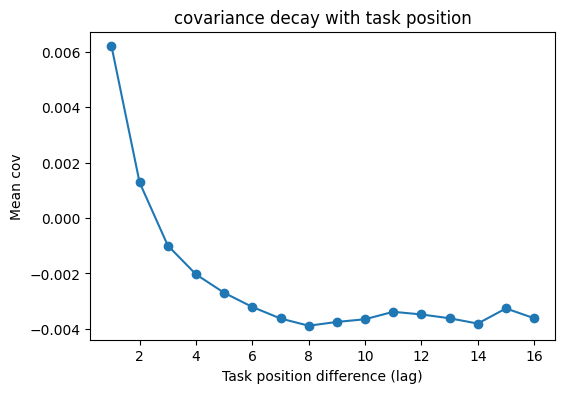

In [15]:
# collect by lag
lags = np.arange(1, n_tasks)   # 1..16
mean_by_lag = []

for lag in lags:
    vals = []
    for i in range(n_tasks - lag):
        vals.append(cov_mat_avg[i, i+lag])
    mean_by_lag.append(np.mean(vals))

mean_by_lag = np.array(mean_by_lag)

plt.figure(figsize=(6,4))
plt.plot(lags, mean_by_lag, marker='o')
plt.xlabel("Task position difference (lag)")
plt.ylabel("Mean cov")
plt.title("covariance decay with task position")
plt.show()



# Cortex

In [16]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
func_fus_dir = os.path.join(data_path, 'FunctionalFusion_new')

MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')
subj = None
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='TaskRun',subj=subj)
# nans to 0
data_mdtb_s1_run = np.nan_to_num(data_mdtb_s1_run)
n_sub, n_reg,n_vox = data_mdtb_s1_run.shape

cond_vec = info_mdtb_1_run['task_num'].values
part_vec  = info_mdtb_1_run["run"].values

# Remove task mean from each task condition for all runs
data_residual = data_mdtb_s1_run.copy()
for t in np.unique(cond_vec):
    mask = (cond_vec == t)
    task_mean = data_mdtb_s1_run[:, mask, :].mean(axis=1, keepdims=True)
    data_residual[:, mask, :] = data_mdtb_s1_run[:, mask, :] - task_mean
    

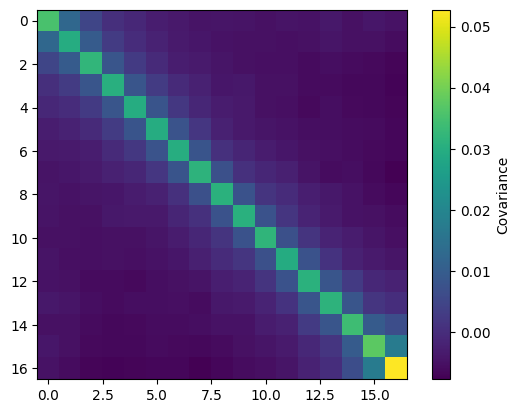

In [17]:
# add true order to info
info_with_order = ut.add_original_order(info_mdtb_1_run,filtered_dat)

# get the sort order based on (run, task_num_orig)
sort_order = info_with_order.sort_values(by=["run", "task_num_orig"]).index


# resort the info and data using the task_num_orig
info_sorted = info_with_order.loc[sort_order].reset_index(drop=True)
data_sorted = data_residual[:, sort_order, :]


n_runs = len(np.unique(info_sorted["run"]))
n_tasks = len(np.unique(info_sorted["task_num_orig"]))

cov_mats_runs = np.zeros((n_sub, n_runs, n_tasks, n_tasks))
for r, run in enumerate(np.unique(info_sorted["run"])):
    mask = info_sorted["run"].values == run
    conds = info_sorted.loc[mask, "task_num_orig"].values

    for s in range(n_sub):
        X = data_sorted[s, mask, :] 
        cov_mats_runs[s, r] = np.cov(X, rowvar=True)

cov_mats_per_subj = cov_mats_runs.mean(axis=1)
cov_mat_avg = cov_mats_per_subj.mean(axis=0)

plt.imshow(cov_mat_avg, cmap='viridis')
plt.colorbar(label='Covariance')


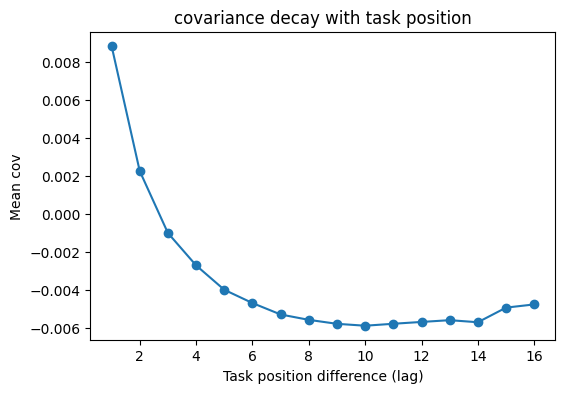

In [18]:
# collect by lag
lags = np.arange(1, n_tasks)   # 1..16
mean_by_lag = []

for lag in lags:
    vals = []
    for i in range(n_tasks - lag):
        vals.append(cov_mat_avg[i, i+lag])
    mean_by_lag.append(np.mean(vals))

mean_by_lag = np.array(mean_by_lag)

plt.figure(figsize=(6,4))
plt.plot(lags, mean_by_lag, marker='o')
plt.xlabel("Task position difference (lag)")
plt.ylabel("Mean cov")
plt.title("covariance decay with task position")
plt.show()

